# Regional fields over heavily-constrained, outcropping targets

When we invert gravity data for a buried interface (here, a sediment&ndash;basement
contact), two things routinely happen together in real surveys:

1. **A strong regional field.** A deep, long-wavelength source (a Moho step, a deep
   density boundary) adds tens of mGal that has nothing to do with the interface we
   want. It must be estimated and removed before the inversion.
2. **A heavily constrained target with a large outcropping region.** Over the outcrop
   the interface *is* the topographic surface, so its depth is known and the prisms
   there cannot move. Constraint points (outcrops, boreholes, seismic picks) are almost
   always concentrated **around** the feature of interest &mdash; a basin, say &mdash;
   because that is where the interface is shallow and easy to sample.

This combination creates two distinct pathologies:

* **Pathology A &mdash; the outcrop artifact.** All the gravity signal over the outcrop
  is "unused": those prisms are fixed. If any misfit remains there (an imperfectly
  removed regional, or noise), the solver cannot absorb it with the fixed prisms, so it
  distorts the *nearest unconstrained* prisms instead &mdash; a ring of spurious
  topography hugging the outcrop edge.
* **Pathology B &mdash; regional masking of a ringed target.** *Constraint-point
  minimization* (CPM) estimates the regional by interpolating the misfit sampled at the
  constraints, where we know the residual should be ~0. But when the target is **ringed**
  by constraints, the broad tail of the target's own gravity anomaly leaks out to that
  ring. The interpolated "regional" absorbs that tail and, when subtracted, **masks a
  large part of the residual** &mdash; the recovered basin comes out far too shallow.

This notebook builds a controlled synthetic that exhibits **both** pathologies, then
compares the tools *Invert4Geom* offers for dealing with them &mdash; constraint-point
minimization, **correction-weighting grids**, **residual-weighting grids** &mdash; and
investigates several new ideas: **depth-controlled equivalent-source regionals**,
**iterative regional refinement**, and simply **breaking the ring** with a few interior
constraints. Throughout we score each method against the *true* answer, paying special
attention to the **basin interior**, which is where masking does its damage.

## Import packages

In [20]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import verde as vd
import xarray as xr

import invert4geom

rng = np.random.default_rng(0)

## Build the synthetic scenario

We create a domain with:

* a flat **surface** at 0 m (the erosion level / land surface),
* a broad, deep central **basin** in the basement that rises to and **outcrops** at the
  surface everywhere outside the basin,
* a deep, smooth **Moho** whose gravity effect is our strong **regional** field.

The basement outcrops (basement = surface = 0) over the entire frame surrounding the
basin, so any constraints we place on the outcrop will *ring* the basin.

In [21]:
region = (0, 40000, 0, 30000)
spacing = 1500

easting, northing = vd.grid_coordinates(region=region, spacing=spacing)


def gaussian(x0, y0, sx, sy):
    return np.exp(
        -(((easting - x0) ** 2) / (2 * sx**2) + ((northing - y0) ** 2) / (2 * sy**2))
    )


# flat surface at 0 m
surface = xr.DataArray(
    np.zeros_like(easting),
    coords={"northing": northing[:, 0], "easting": easting[0, :]},
    dims=("northing", "easting"),
)

# broad, deep central basin; rises above the surface (+400 m) away from the centre
basin_centre = (20000, 15000)
basin_shape = -2600.0 * gaussian(*basin_centre, 9000, 7000) + 400.0

# the true basement is the basin where it is below the surface, and outcrops (== surface)
# everywhere else
true_basement = xr.where(basin_shape < surface, basin_shape, surface).rename("upward")

# a boolean grid of the outcropping region (basement == surface)
is_outcrop = np.isclose(true_basement.values, surface.values)

# the deep Moho -> long-wavelength regional
moho = invert4geom.synthetic_topography_regional(
    spacing=spacing, region=region, scale=25, yoffset=-13000
)

print(
    f"basement depth range: {float(true_basement.min()):.0f} to {float(true_basement.max()):.0f} m"
)
print(f"outcropping cells: {is_outcrop.sum()} of {true_basement.size}")

basement depth range: -2191 to 0 m
outcropping cells: 256 of 588


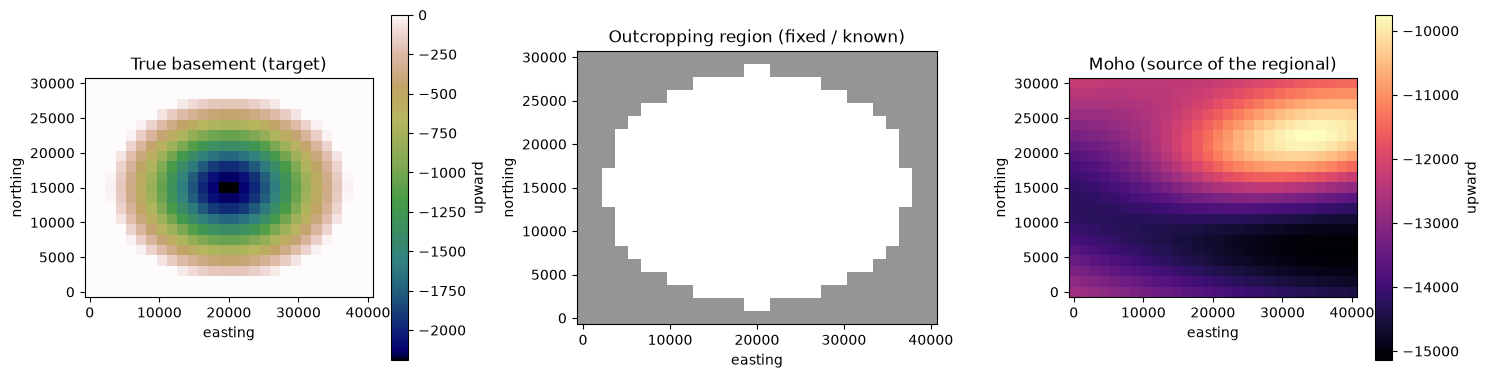

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
true_basement.plot(ax=axes[0], cmap="gist_earth")
axes[0].set_title("True basement (target)")
xr.where(xr.DataArray(is_outcrop, coords=true_basement.coords), 1, np.nan).plot(
    ax=axes[1], add_colorbar=False, cmap="Greys"
)
axes[1].set_title("Outcropping region (fixed / known)")
moho.plot(ax=axes[2], cmap="magma")
axes[2].set_title("Moho (source of the regional)")
for ax in axes:
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### Forward-model the gravity

The observed gravity is the sum of the **basement** effect (our target / residual source)
and the **Moho** effect (the regional). We keep both true fields around so we can score
every method against them later.

In [23]:
zref = float(true_basement.mean())
density_contrast = 400  # basement (2800) - sediment fill (2400) kg/m3

true_model = invert4geom.create_model(
    zref=zref,
    density_contrast=density_contrast,
    topography=true_basement.to_dataset(name="upward"),
)
moho_model = invert4geom.create_model(
    zref=float(moho.mean()),
    density_contrast=500,  # mantle (3300) - crust (2800)
    topography=moho.to_dataset(name="upward"),
)

obs = vd.make_xarray_grid(
    (easting, northing),
    data=(np.zeros_like(easting), np.full_like(easting, 1000.0)),
    data_names=("gravity_anomaly", "upward"),
)
data = invert4geom.create_data(obs)
data.inv.forward_gravity(true_model, name="basement_grav", progressbar=False)
data.inv.forward_gravity(moho_model, name="moho_grav", progressbar=False)

# use a zero-mean regional so the constant offset does not confuse the comparison
data["moho_grav"] = data.moho_grav - float(data.moho_grav.mean())

gravity_noise = 0.1
noise_free = (data.basement_grav + data.moho_grav).rename("gravity_anomaly")
data["gravity_anomaly"], _ = invert4geom.synthetic.contaminate(
    noise_free, stddev=gravity_noise, seed=0
)

# store the TRUE regional and residual for scoring
data["true_reg"] = data.moho_grav
data["true_res"] = data.basement_grav

print(
    f"regional (Moho)  peak-to-peak: {float(data.moho_grav.max() - data.moho_grav.min()):.1f} mGal"
)
print(
    f"residual (basin) peak-to-peak: {float(data.basement_grav.max() - data.basement_grav.min()):.1f} mGal"
)

regional (Moho)  peak-to-peak: 12.1 mGal
residual (basin) peak-to-peak: 23.8 mGal


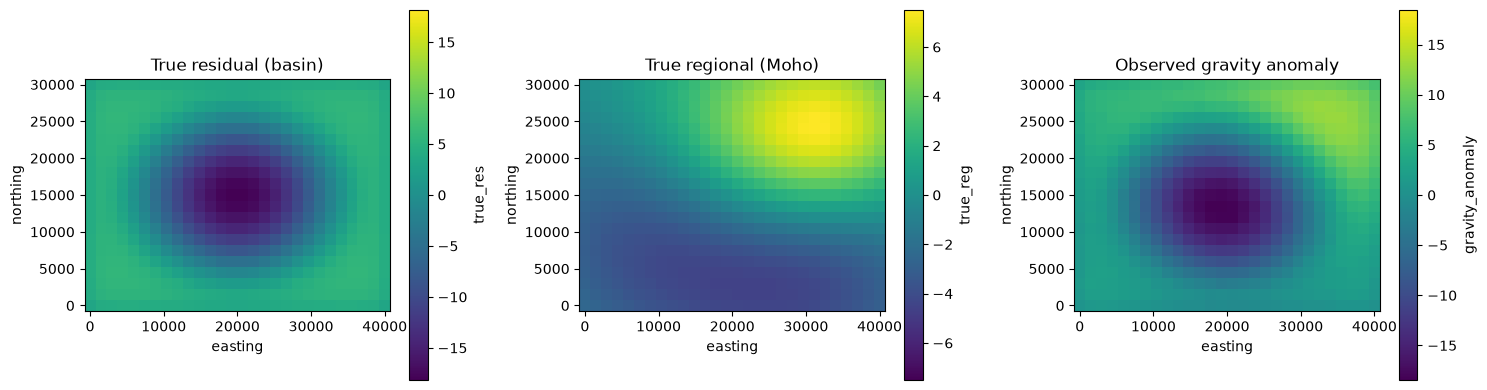

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
data.true_res.plot(ax=axes[0], cmap="viridis")
axes[0].set_title("True residual (basin)")
data.true_reg.plot(ax=axes[1], cmap="viridis")
axes[1].set_title("True regional (Moho)")
data.gravity_anomaly.plot(ax=axes[2], cmap="viridis")
axes[2].set_title("Observed gravity anomaly")
for ax in axes:
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### Constraints that ring the basin, and the starting model

We sample constraint points **only on the outcrop** &mdash; nowhere inside the basin.
This is the "ringed" geometry. The starting model interpolates those constraints, so it
is ~flat at the surface everywhere (all constraints have `upward = 0`).

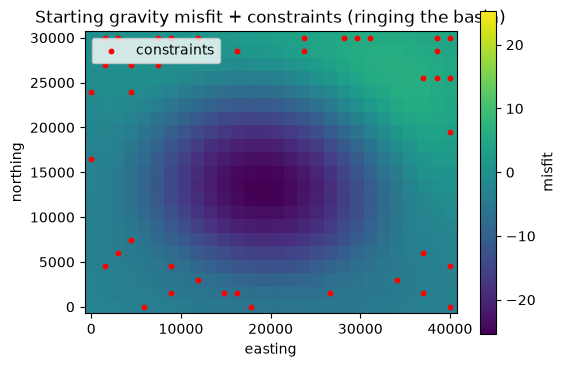

In [25]:
outcrop_df = (
    true_basement.where(xr.DataArray(is_outcrop, coords=true_basement.coords))
    .to_dataframe(name="upward")
    .reset_index()
    .dropna()
)
constraint_points = outcrop_df.sample(40, random_state=1).reset_index(drop=True)
constraint_points["upward"] = 0.0

starting_topography = invert4geom.create_topography(
    method="splines",
    region=region,
    spacing=spacing,
    constraints_df=constraint_points,
    dampings=None,
)
starting_model = invert4geom.create_model(
    zref=zref,
    density_contrast=density_contrast,
    topography=starting_topography,
)
data.inv.forward_gravity(starting_model, progressbar=False)
data.inv.regional_separation(
    method="constant", constant=0
)  # initialises misfit/reg/res

fig, ax = plt.subplots(figsize=(6, 4.2))
data.misfit.plot(ax=ax, cmap="viridis")
ax.scatter(
    constraint_points.easting,
    constraint_points.northing,
    c="red",
    s=10,
    label="constraints",
)
ax.set_aspect("equal")
ax.set_title("Starting gravity misfit + constraints (ringing the basin)")
ax.legend()
plt.show()

The constraints (red) form a frame around the central basin. The misfit over the basin is
`basin residual + regional`; over the outcrop it is `regional` alone (the residual there
should be zero). Every method below must decide how much of the misfit is regional.

## Scoring

We define three region masks and score every result the same way:

* **whole** &mdash; RMSE of recovered vs true basement over the entire domain,
* **interior** &mdash; RMSE over the **basin interior** only (where masking hurts),
* **outcrop artifact** &mdash; RMSE of the recovered topography over the outcrop away from
  the basin (should be ~0; non-zero means Pathology A).

We also track the RMSE of the estimated **regional** vs the true regional.

In [26]:
interior_mask = gaussian(*basin_centre, 9000, 7000) > 0.3  # basin interior
outcrop_artifact_mask = is_outcrop & ~interior_mask  # outcrop, away from basin


def evaluate(name, inv, reg=None, note=""):
    err = (inv.model.topography - true_basement).values
    row = {
        "method": name,
        "whole": invert4geom.rmse(err),
        "interior": invert4geom.rmse(err[interior_mask]),
        "outcrop_artifact": invert4geom.rmse(err[outcrop_artifact_mask]),
        "reg_RMSE": np.nan
        if reg is None
        else invert4geom.rmse((reg - data.true_reg).values),
        "note": note,
    }
    results.append(row)
    print(
        f"{name:32s}  whole={row['whole']:6.1f}  interior={row['interior']:6.1f}  "
        f"outcrop={row['outcrop_artifact']:6.1f}  regRMSE={row['reg_RMSE']:.2f}"
    )
    return row


# shared inversion settings
INV = dict(
    solver_damping=0.02,
    max_iterations=60,
    l2_norm_tolerance=np.sqrt(gravity_noise),
    delta_l2_norm_tolerance=1.001,
)


def run_inversion(grav, model=None):
    inv = invert4geom.Inversion(
        copy.deepcopy(grav),
        copy.deepcopy(model if model is not None else starting_model),
        **INV,
    )
    inv.invert(progressbar=False)
    return inv


def compare_topography(inv, title):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    true_basement.plot(ax=axes[0], cmap="gist_earth")
    axes[0].set_title("True basement")
    inv.model.topography.plot(ax=axes[1], cmap="gist_earth")
    axes[1].set_title("Recovered")
    (inv.model.topography - true_basement).plot(
        ax=axes[2], cmap="RdBu", vmin=-800, vmax=800
    )
    axes[2].set_title("Recovered - true (error)")
    for ax in axes:
        ax.scatter(constraint_points.easting, constraint_points.northing, c="k", s=4)
        ax.set_aspect("equal")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## Reference: the achievable floor (true regional)

If we hand the inversion the *true* regional, how well can the ringed basin be recovered?
This is the best any method could hope for &mdash; the noise- and discretization-limited
floor.

oracle (true regional)            whole=  11.5  interior=  12.6  outcrop=  10.4  regRMSE=0.00


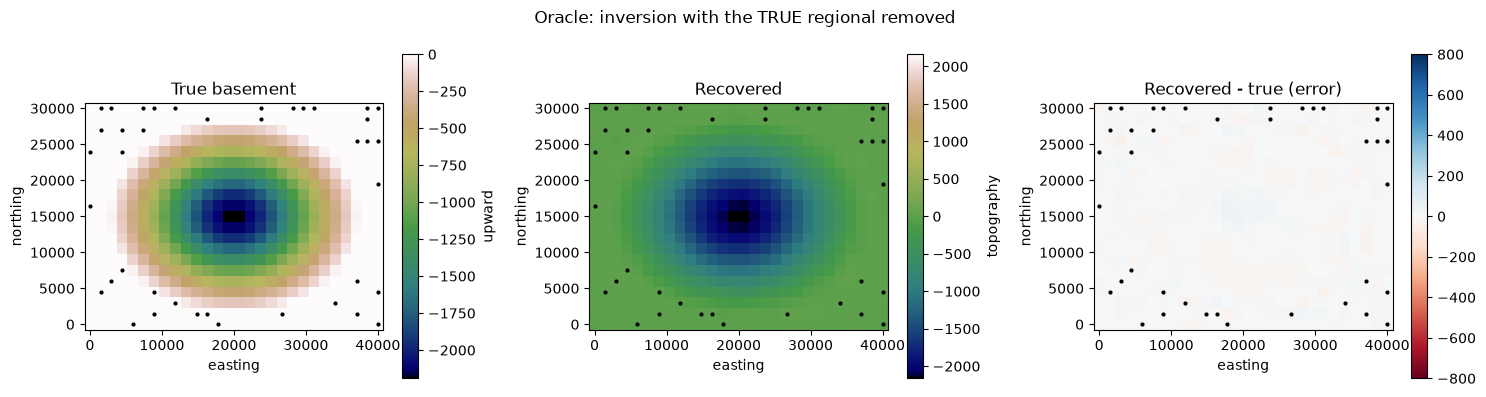

In [27]:
d = copy.deepcopy(data)
d["reg"] = d.true_reg
d["res"] = d.misfit - d.reg
inv_oracle = run_inversion(d)
evaluate("oracle (true regional)", inv_oracle, reg=d.reg, note="best achievable")
compare_topography(inv_oracle, "Oracle: inversion with the TRUE regional removed")

The basin is recovered cleanly. Every method below is trying to close the gap to this
floor **without** knowing the true regional.

## Pathology A + B together: the naive approach

The most naive workflow: assume the Bouguer correction removed the regional (so use a
constant regional of 0) and **mask** the outcropping prisms to hold them fixed. Because
the strong regional is *not* actually removed, misfit remains over the outcrop, and the
fixed prisms force it into their neighbours.

naive (reg=0, masked outcrop)     whole= 313.5  interior= 288.4  outcrop= 329.1  regRMSE=3.73


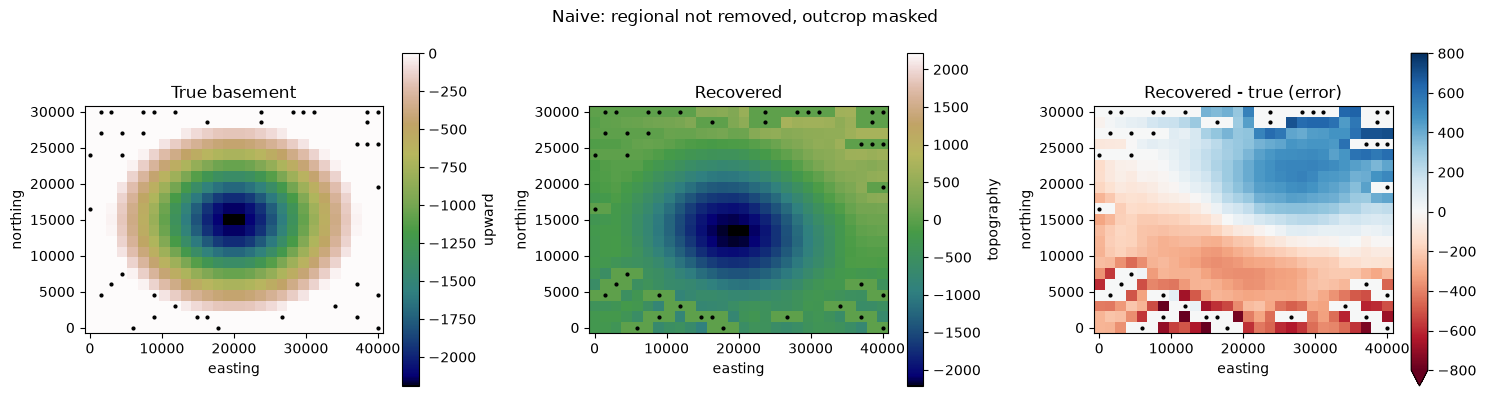

In [28]:
masked_topography = starting_topography.copy()
dist_to_constraint = invert4geom.normalized_mindist(
    constraint_points, starting_topography.upward
)
masked_topography["mask"] = xr.where(dist_to_constraint < spacing, np.nan, 1)
masked_model = invert4geom.create_model(
    zref=zref,
    density_contrast=density_contrast,
    topography=masked_topography,
)

d = copy.deepcopy(data)
d.inv.forward_gravity(masked_model, progressbar=False)
d.inv.regional_separation(method="constant", constant=0)
inv_naive = run_inversion(d, model=masked_model)
evaluate("naive (reg=0, masked outcrop)", inv_naive, reg=d.reg, note="both pathologies")
compare_topography(inv_naive, "Naive: regional not removed, outcrop masked")

Two failures at once: the interior is wrong (the regional leaks in as false residual) and
a ring of spurious topography hugs the outcrop (Pathology A). We now take the pathologies
one at a time.

## Weighting grids: a local tool for the outcrop artifact (Pathology A)

*Invert4Geom* offers two weighting grids, both built from
`normalized_mindist` (0 at the constraints, ramping to 1 away from them):

* **Correction-weighting grid** (`apply_weighting_grid`): multiplies each iteration's
  topography *correction*, so prisms near constraints barely move.
* **Residual-weighting grid** (`apply_residual_weighting_grid`): multiplies the residual
  gravity *before* the solve, so the solver never sees misfit at the constraints.

Both damp the solver near the constraints. Neither, on its own, removes the regional
&mdash; so with `reg = 0` the interior stays biased. They are tools for Pathology A, not B,
and as we will see they only partly fix even that while a strong regional remains.

Inversion terminated due to max_iterations limit. Consider increasing this limit.


correction-weight (reg=0)         whole= 277.3  interior= 295.9  outcrop= 257.8  regRMSE=3.73


Inversion terminated due to max_iterations limit. Consider increasing this limit.


residual-weight (reg=0)           whole= 269.3  interior= 292.5  outcrop= 244.1  regRMSE=3.73


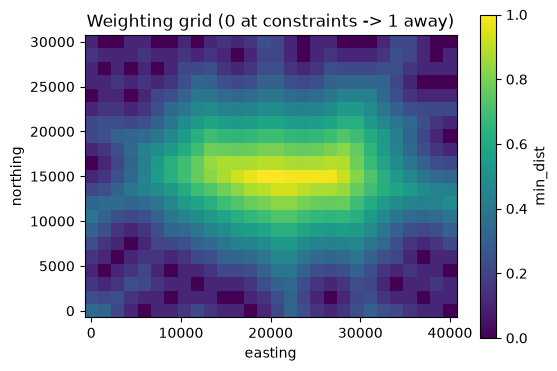

In [29]:
weighting_grid = invert4geom.normalized_mindist(
    constraint_points, starting_topography.upward, low=0, high=1
)

# correction weighting, regional still 0
d = copy.deepcopy(data)
inv_cw = invert4geom.Inversion(
    d,
    copy.deepcopy(starting_model),
    apply_weighting_grid=True,
    weighting_grid=weighting_grid,
    **INV,
)
inv_cw.invert(progressbar=False)
evaluate(
    "correction-weight (reg=0)",
    inv_cw,
    reg=d.reg,
    note="local tool; regional dominates",
)

# residual weighting, regional still 0
d = copy.deepcopy(data)
inv_rw = invert4geom.Inversion(
    d,
    copy.deepcopy(starting_model),
    apply_residual_weighting_grid=True,
    residual_weighting_grid=weighting_grid,
    **INV,
)
inv_rw.invert(progressbar=False)
evaluate(
    "residual-weight (reg=0)", inv_rw, reg=d.reg, note="local tool; regional dominates"
)

fig, ax = plt.subplots(figsize=(6, 4.2))
weighting_grid.plot(ax=ax, cmap="viridis")
ax.set_aspect("equal")
ax.set_title("Weighting grid (0 at constraints -> 1 away)")
plt.show()

Notice how little this buys us. The outcrop artifact does come down (roughly a quarter
below the naive run), but the interior is no better &mdash; if anything slightly worse.

A weighting grid only quietens the immediate neighbourhood of each constraint. With a
strong regional still in the data the misfit biases the **entire** outcrop frame, most of
which lies far from any of the 40 sparse constraints, where the weight is already ~1. So
the artifact is only partly suppressed and the interior bias is untouched. Weighting grids
are a *local* tool: they pay off once the regional has been removed (we combine them with
CPM below). First, then, we must estimate the regional.

## Constraint-point minimization (CPM) and the masking problem (Pathology B)

CPM interpolates the misfit sampled at the constraints to build the regional. It removes
the regional *and* zeroes the residual at the outcrop (so no artifact) &mdash; but because
the basin is ringed, the interpolant absorbs the tail of the basin's own anomaly and
masks the interior residual.

*Invert4Geom* can grid the constraint-point misfit three ways, and we test all of them:

* **`verde`** &mdash; bi-harmonic spline (damping cross-validated),
* **`pygmt`** &mdash; tensioned minimum-curvature surface (`tension_factor`),
* **`eq_sources`** &mdash; deep equivalent sources (`depth`).

All three remove the regional and clear the outcrop artifact, and all three mask the
interior to some degree &mdash; how much depends on how flexible the interpolant is over
the un-sampled basin.

CPM (verde)                       whole= 166.6  interior= 253.7  outcrop=  57.0  regRMSE=2.21
CPM (pygmt0)                      whole= 162.1  interior= 243.6  outcrop=  62.2  regRMSE=2.15
CPM (pygmt1)                      whole= 142.8  interior= 189.8  outcrop=  96.3  regRMSE=1.81
CPM (eq_sources)                  whole= 174.9  interior= 269.6  outcrop=  52.7  regRMSE=2.30


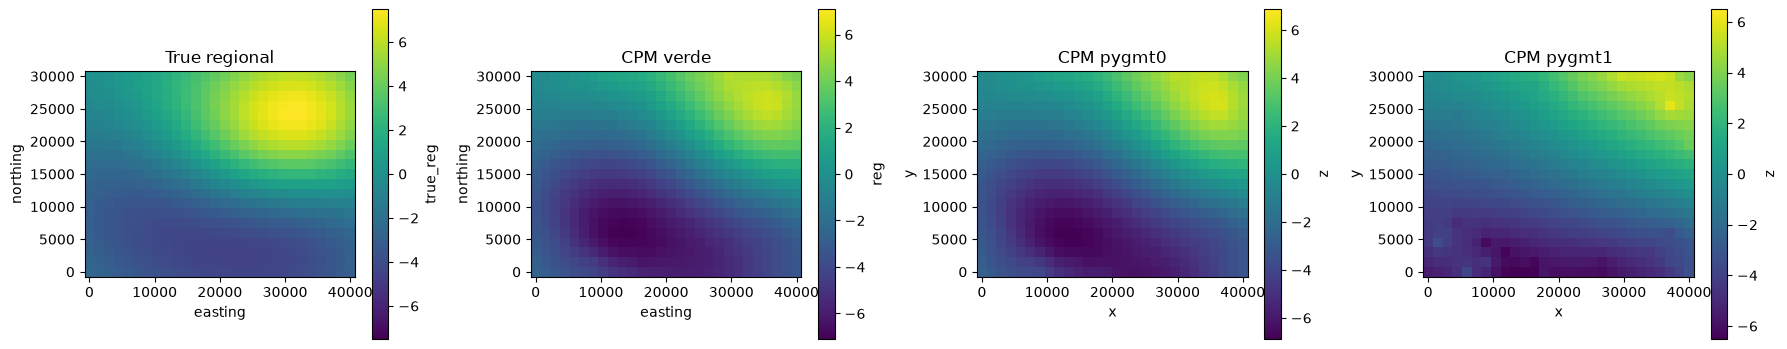

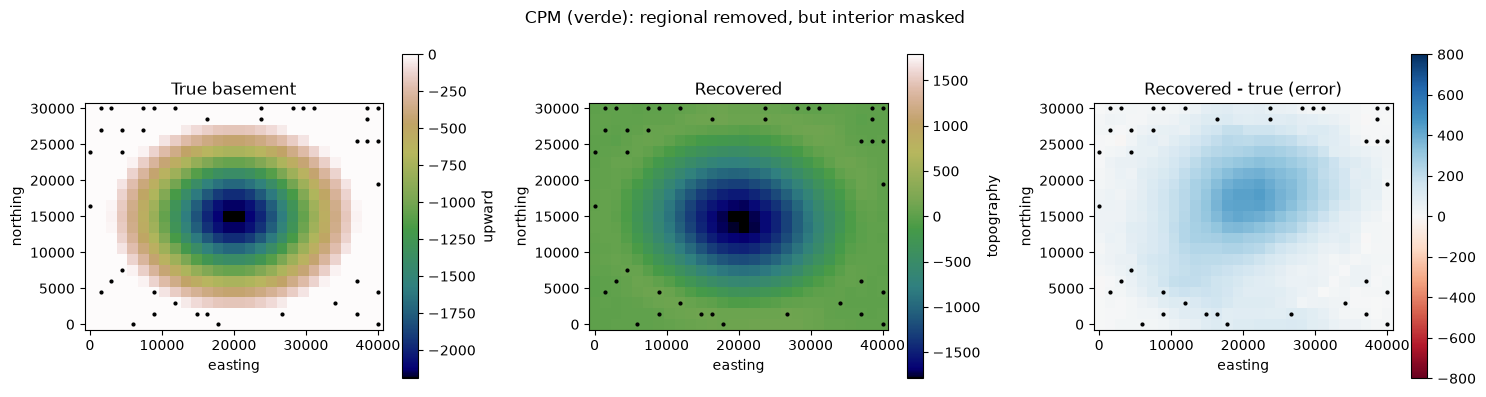

In [30]:
cpm_methods = {
    "verde": dict(grid_method="verde", spline_dampings=[None, 1e-2, 1e0]),
    "pygmt0": dict(grid_method="pygmt", tension_factor=0),
    "pygmt1": dict(grid_method="pygmt", tension_factor=1),
    "eq_sources": dict(grid_method="eq_sources", depth=10000),
}
results = []
cpm_regionals = {}
inv_cpm = None
for name, kw in cpm_methods.items():
    d = copy.deepcopy(data)
    d.inv.regional_separation(
        method="constraints", constraints_df=constraint_points, **kw
    )
    inv_m = run_inversion(d)
    evaluate(f"CPM ({name})", inv_m, reg=d.reg, note="masks the interior")
    cpm_regionals[name] = d.reg.copy()
    if name == "verde":
        inv_cpm = inv_m  # keep the verde result for the topography figure

# the estimated regionals vs the truth
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
data.true_reg.plot(ax=axes[0], cmap="viridis")
axes[0].set_title("True regional")
for ax, name in zip(axes[1:], cpm_methods):
    cpm_regionals[name].plot(ax=ax, cmap="viridis")
    ax.set_title(f"CPM {name}")
for ax in axes:
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

compare_topography(inv_cpm, "CPM (verde): regional removed, but interior masked")

Each CPM regional dips into the basin where there are no constraints: it has swallowed part
of the basin's gravity low, so the recovered basin comes out much too shallow in the middle.
The three differ in *how much* they mask: `pygmt`'s tensioned surface is stiffer over the
un-sampled basin than `verde`'s bi-harmonic spline and so masks noticeably less, while
`eq_sources` gives us an extra, physically meaningful knob &mdash; the source depth &mdash;
that sets the regional's wavelength directly. This is exactly
the masking the question is about.

### Does the regional's stiffness help? A depth sweep

The equivalent-source variant of CPM lets us control the regional's **wavelength** through
the source `depth`: deeper sources can only make longer-wavelength regionals, which are
harder to bow into the basin. But go too deep and the regional can no longer follow the
true regional gradient at all. There is a sweet spot &mdash; and no monotone "deeper is
better" rule.

 depth   interior  reg_RMSE
  1500 214.771965  1.986373
  2500 199.074048  1.806769
  4000 190.976289  1.746275
  7000 216.267476  1.950290
 12000 311.743421  2.561142
 20000 427.747978  3.360256


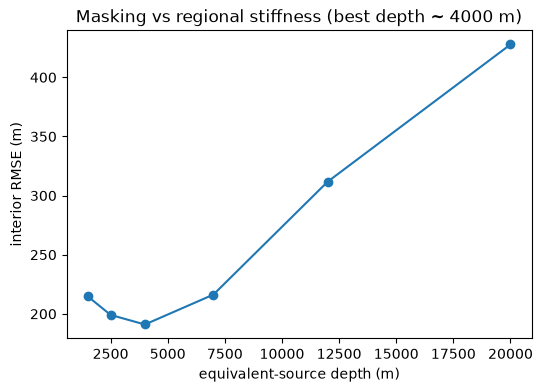

In [31]:
depth_sweep = [1500, 2500, 4000, 7000, 12000, 20000]
sweep_rows = []
for depth in depth_sweep:
    d = copy.deepcopy(data)
    d.inv.regional_separation(
        method="constraints",
        constraints_df=constraint_points,
        grid_method="eq_sources",
        depth=depth,
        damping=None,
    )
    inv_d = run_inversion(d)
    err = (inv_d.model.topography - true_basement).values
    sweep_rows.append(
        {
            "depth": depth,
            "interior": invert4geom.rmse(err[interior_mask]),
            "reg_RMSE": invert4geom.rmse((d.reg - data.true_reg).values),
        }
    )
sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.to_string(index=False))

best_depth = int(sweep_df.loc[sweep_df.interior.idxmin(), "depth"])
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sweep_df.depth, sweep_df.interior, "o-")
ax.set_xlabel("equivalent-source depth (m)")
ax.set_ylabel("interior RMSE (m)")
ax.set_title(f"Masking vs regional stiffness (best depth ~ {best_depth} m)")
plt.show()

Record the best single-shot equivalent-source CPM, and pair it with a residual-weighting
grid to also clean up the outcrop &mdash; the best result achievable with the library's
existing tools.

In [32]:
d = copy.deepcopy(data)
d.inv.regional_separation(
    method="constraints",
    constraints_df=constraint_points,
    grid_method="eq_sources",
    depth=best_depth,
)
inv_eqs = run_inversion(d)
evaluate(
    f"CPM eq-sources (depth={best_depth})",
    inv_eqs,
    reg=d.reg,
    note="best single-shot CPM",
)

d = copy.deepcopy(data)
d.inv.regional_separation(
    method="constraints",
    constraints_df=constraint_points,
    grid_method="eq_sources",
    depth=best_depth,
)
inv_eqs_rw = invert4geom.Inversion(
    d,
    copy.deepcopy(starting_model),
    apply_residual_weighting_grid=True,
    residual_weighting_grid=weighting_grid,
    **INV,
)
inv_eqs_rw.invert(progressbar=False)
evaluate(
    "CPM eq-sources + residual weight", inv_eqs_rw, reg=d.reg, note="best library combo"
)

CPM eq-sources (depth=4000)       whole= 135.8  interior= 191.0  outcrop=  64.9  regRMSE=1.75


Inversion terminated due to max_iterations limit. Consider increasing this limit.


CPM eq-sources + residual weight  whole= 133.4  interior= 193.6  outcrop=  48.5  regRMSE=1.75


{'method': 'CPM eq-sources + residual weight',
 'whole': np.float64(133.35549728299907),
 'interior': np.float64(193.6386760545031),
 'outcrop_artifact': np.float64(48.521395454762896),
 'reg_RMSE': np.float64(1.746274908954357),
 'note': 'best library combo'}

### Cross-validated CPM

Rather than hand-pick the depth, we can cross-validate it. *Invert4Geom* splits the
constraints into K folds and optimizes the equivalent-source parameters by minimizing the
residual at held-out constraints while **maximizing the residual amplitude** (an explicit
anti-masking term). A caveat worth seeing for yourself: in a fully ringed geometry the
amplitude objective tends to pull the regional toward the *smoothest* (deepest) option,
because a flat regional trivially maximizes residual amplitude. We cap the depth range to
keep it sensible.

In [33]:
split_df = invert4geom.split_test_train(
    constraint_points,
    method="KFold",
    n_splits=4,
    coord_names=("easting", "northing"),
)
gd = copy.deepcopy(data)
study, gd, best_trial = invert4geom.optimize_regional_constraint_point_minimization(
    grav_ds=gd,
    testing_training_df=split_df,
    grid_method="eq_sources",
    depth_limits=(4000.0, 16000.0),
    n_trials=12,
    progressbar=False,
    plot=False,
    seed=0,
)
print("CV-selected params:", best_trial.params)
inv_cv = run_inversion(gd)
evaluate("CPM eq-sources (CV depth)", inv_cv, reg=gd.reg, note="cross-validated")

CV-selected params: {'depth': 15391.361727286261}
CPM eq-sources (CV depth)         whole= 227.1  interior= 362.0  outcrop=  47.5  regRMSE=2.91


{'method': 'CPM eq-sources (CV depth)',
 'whole': np.float64(227.0958340584794),
 'interior': np.float64(362.00312529482085),
 'outcrop_artifact': np.float64(47.48520217149375),
 'reg_RMSE': np.float64(2.9146490022775957),
 'note': 'cross-validated'}

## Iterative regional refinement: stable, but it converges to the wrong answer

If CPM masks the basin because the basin's own tail contaminates the constraint samples,
why not **peel it off**? Invert, forward-model the recovered basin, subtract its gravity
from the misfit at the constraints, and re-estimate the regional &mdash; then repeat.

Starting from the best single-shot regional above, this turns out to be perfectly well
behaved: the interior error decreases steadily and has flattened off after a handful of
passes.
But look at *where* it settles. The gain is small, and the converged answer is still an
order of magnitude above the oracle floor.

The reason is that the iteration has a **biased fixed point**. At a ring of constraints the
regional and the smooth *tail* of the basin anomaly are genuinely indistinguishable, so
whatever leakage the interpolant is able to reproduce is simply re-absorbed on the next
pass. Peeling removes only the part of the leakage the interpolant *cannot* represent; the
rest is a stable attractor that is not the truth. Refinement is safe to run &mdash; it just
cannot manufacture the missing information.

interior RMSE per iteration: [np.float64(191.0), np.float64(188.7), np.float64(187.5), np.float64(186.9), np.float64(186.8), np.float64(186.9)]


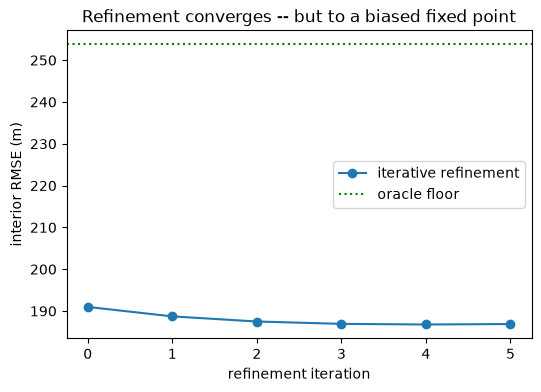

iterative refine (converged)      whole= 136.1  interior= 186.9  outcrop=  78.2  regRMSE=1.73


{'method': 'iterative refine (converged)',
 'whole': np.float64(136.14622709764248),
 'interior': np.float64(186.8851596302408),
 'outcrop_artifact': np.float64(78.16532069198615),
 'reg_RMSE': np.float64(1.7277645290925576),
 'note': 'stable, but biased fixed point'}

In [34]:
# start from the best single-shot regional and try to peel the basin off it
iter_depth = best_depth
d = copy.deepcopy(data)
d.inv.regional_separation(
    method="constraints",
    constraints_df=constraint_points,
    grid_method="eq_sources",
    depth=iter_depth,
)
reg = d.reg.copy()
iter_hist = []
iter_cache = []
for it in range(6):
    d["reg"] = reg
    d["res"] = d.misfit - reg
    inv_it = run_inversion(d)
    err = (inv_it.model.topography - true_basement).values
    iter_hist.append(invert4geom.rmse(err[interior_mask]))
    iter_cache.append((inv_it, reg.copy()))
    # peel: re-estimate the regional from the misfit minus the recovered basin's gravity
    d2 = copy.deepcopy(data)
    d2.inv.forward_gravity(inv_it.model, progressbar=False)
    d2.inv.regional_separation(
        method="constraints",
        constraints_df=constraint_points,
        grid_method="eq_sources",
        depth=iter_depth,
    )
    reg = d2.reg

print("interior RMSE per iteration:", [round(v, 1) for v in iter_hist])
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(len(iter_hist)), iter_hist, "o-", label="iterative refinement")
ax.axhline(results[0]["interior"], ls=":", c="green", label="oracle floor")
ax.set_xlabel("refinement iteration")
ax.set_ylabel("interior RMSE (m)")
ax.set_title("Refinement converges -- but to a biased fixed point")
ax.legend()
plt.show()

inv_iter, reg_iter = iter_cache[-1]
evaluate(
    "iterative refine (converged)",
    inv_iter,
    reg=reg_iter,
    note="stable, but biased fixed point",
)

So refinement is not dangerous, merely disappointing: **the information needed to separate
regional from residual over the basin is not in the ring**, and no interpolation or
iteration scheme can create it.

## What actually works: break the ring

If the masking is caused by the *geometry* &mdash; constraints only *around* the target
&mdash; then the effective cure is to obtain a few constraints **inside** it (a borehole, a
seismic pick, a single deep sounding). Even one interior point helps materially, and a
handful roughly halves the interior error &mdash; a larger gain than any of the
regional-estimation tricks above.

 interior_constraints  interior_RMSE
                    0     253.747022
                    1     173.300505
                    6     125.807940
                   12     132.410475


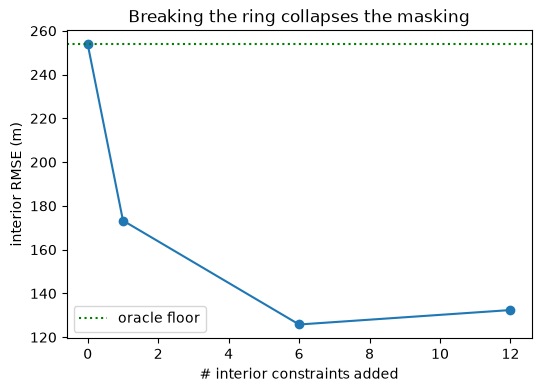

In [35]:
interior_truth = true_basement.to_dataframe(name="upward").reset_index()
interior_truth = interior_truth[interior_mask.ravel()]

ring_rows = []
inv_ring_examples = {}
for k in [0, 1, 6, 12]:
    if k == 0:
        cp = constraint_points.copy()
    else:
        add = interior_truth.sample(k, random_state=7)[
            ["easting", "northing", "upward"]
        ]
        cp = pd.concat([constraint_points, add], ignore_index=True)
    start_k = invert4geom.create_topography(
        method="splines",
        region=region,
        spacing=spacing,
        constraints_df=cp,
        dampings=None,
    )
    model_k = invert4geom.create_model(
        zref=zref, density_contrast=density_contrast, topography=start_k
    )
    d = copy.deepcopy(data)
    d.inv.forward_gravity(model_k, progressbar=False)
    d.inv.regional_separation(
        method="constraints",
        constraints_df=cp,
        grid_method="verde",
        spline_dampings=[None, 1e-3, 1e-1],
    )
    inv_k = run_inversion(d, model=model_k)
    err = (inv_k.model.topography - true_basement).values
    ring_rows.append(
        {
            "interior_constraints": k,
            "interior_RMSE": invert4geom.rmse(err[interior_mask]),
        }
    )
    inv_ring_examples[k] = (inv_k, cp, d.reg.copy())
ring_df = pd.DataFrame(ring_rows)
print(ring_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ring_df.interior_constraints, ring_df.interior_RMSE, "o-")
ax.axhline(results[0]["interior"], ls=":", c="green", label="oracle floor")
ax.set_xlabel("# interior constraints added")
ax.set_ylabel("interior RMSE (m)")
ax.set_title("Breaking the ring collapses the masking")
ax.legend()
plt.show()

CPM + 6 interior constraints      whole=  80.4  interior= 125.8  outcrop=  28.2  regRMSE=0.90


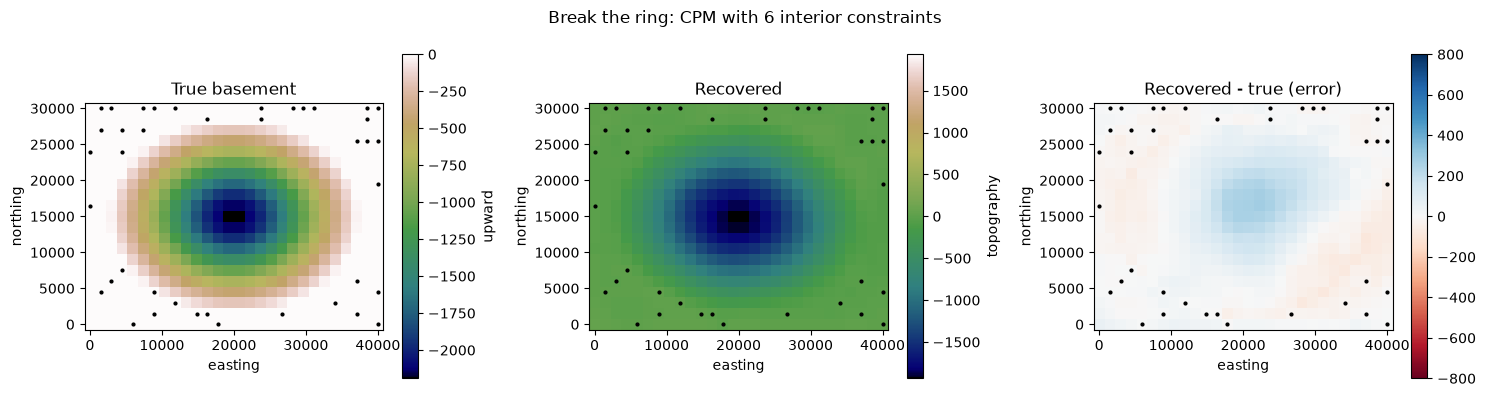

In [36]:
inv_k6, cp6, reg_k6 = inv_ring_examples[6]
evaluate("CPM + 6 interior constraints", inv_k6, reg=reg_k6, note="break the ring")
compare_topography(inv_k6, "Break the ring: CPM with 6 interior constraints")

## Summary

In [37]:
summary = pd.DataFrame(results).set_index("method")
summary_display = summary[
    ["whole", "interior", "outcrop_artifact", "reg_RMSE", "note"]
].round(1)
summary_display

,whole,interior,outcrop_artifact,reg_RMSE,note
method,,,,,
CPM (verde),166.6,253.7,57.0,2.2,masks the interior
CPM (pygmt0),162.1,243.6,62.2,2.1,masks the interior
CPM (pygmt1),142.8,189.8,96.3,1.8,masks the interior
CPM (eq_sources),174.9,269.6,52.7,2.3,masks the interior
CPM eq-sources (depth=4000),135.8,191.0,64.9,1.7,best single-shot CPM
CPM eq-sources + residual weight,133.4,193.6,48.5,1.7,best library combo
CPM eq-sources (CV depth),227.1,362.0,47.5,2.9,cross-validated
iterative refine (converged),136.1,186.9,78.2,1.7,"stable, but biased fixed point"
CPM + 6 interior constraints,80.4,125.8,28.2,0.9,break the ring


KeyError: 'oracle (true regional)'

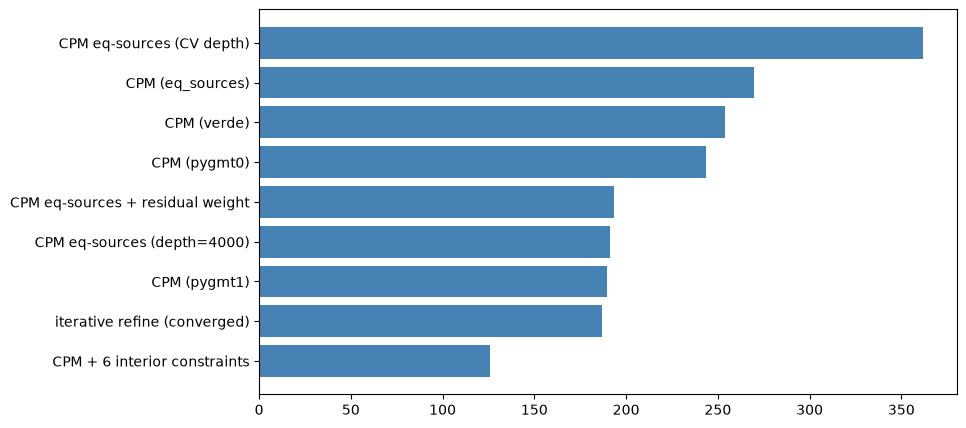

In [38]:
fig, ax = plt.subplots(figsize=(9, 5))
order = summary.sort_values("interior", ascending=True)
ax.barh(order.index, order["interior"], color="steelblue")
ax.axvline(
    summary.loc["oracle (true regional)", "interior"],
    ls="--",
    c="green",
    label="oracle floor",
)
ax.set_xlabel("basin interior RMSE (m)  -  lower is better")
ax.set_title("Interior recovery by method")
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways

* **Two separate problems.** The *outcrop artifact* (Pathology A) and *interior masking*
  (Pathology B) have different cures; don't expect one knob to fix both.
* **Weighting grids are for the artifact, not the regional.** `apply_weighting_grid`
  (corrections) and `apply_residual_weighting_grid` (residual) both suppress the spurious
  ring of topography near constraints, but they do nothing about a strong regional. Use
  them *together with* a regional estimate.
* **CPM removes the regional but masks a ringed target.** The interpolated regional
  absorbs the tail of the target's own anomaly. Controlling the regional's wavelength
  (equivalent-source depth, spline damping, tension) trades masking against regional
  misfit. There is a genuine sweet spot (here, sources a few km deep), but it only
  *reduces* masking. Treat the built-in cross-validation with care in this geometry: its
  residual-amplitude objective favoured a much deeper, over-smooth regional and scored
  clearly worse than a hand-picked depth.
* **Iterative "peeling" converges, but to a biased answer.** Re-estimating the regional
  from the misfit minus the recovered basin is numerically stable and does improve things
  slightly, but its fixed point is not the truth: at a ring, regional and residual tail are
  indistinguishable, so the leakage is re-absorbed on every pass. It cannot recover the
  masked signal.
* **The real fix is geometric: break the ring.** A few constraints *inside* the target cut
  the interior error roughly in half &mdash; a bigger gain than any post-hoc separation
  scheme achieved here &mdash; although a handful of points still does not reach the oracle
  floor. When planning a survey over a basin ringed by outcrop, the highest-value datum is
  a control point in the middle.